In [1]:
import sys

sys.path.append("../")

In [2]:
import cv2 as cv
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sulllam.localization.extraction.orb import ORBFeatureExtractor, ORBConfigs
from sulllam.localization.matching.bf import BFMatcherConfig, BFFeatureMatcher
from sulllam.localization.pose_estimation.eight_point_estimator import EightPointEstimatorConfig, EightPointPoseEstimator

Images:

In [3]:
image_dir = Path("/home/zhukowych/Projects/ucu/MMML/SULLLAM/data/frames_undistorted")
images = [cv.imread(image_path) for image_path in sorted(image_dir.glob("*.png"))]

Camera calibration:

In [4]:
K = np.array([[533.34072745,   0.        , 254.64689388],
              [  0.        , 533.25564953, 256.48354909],
              [  0.        ,   0.        ,   1.        ]])

ORB keypoint extractor

In [5]:
orb_config = ORBConfigs()
orb_extrator = ORBFeatureExtractor()

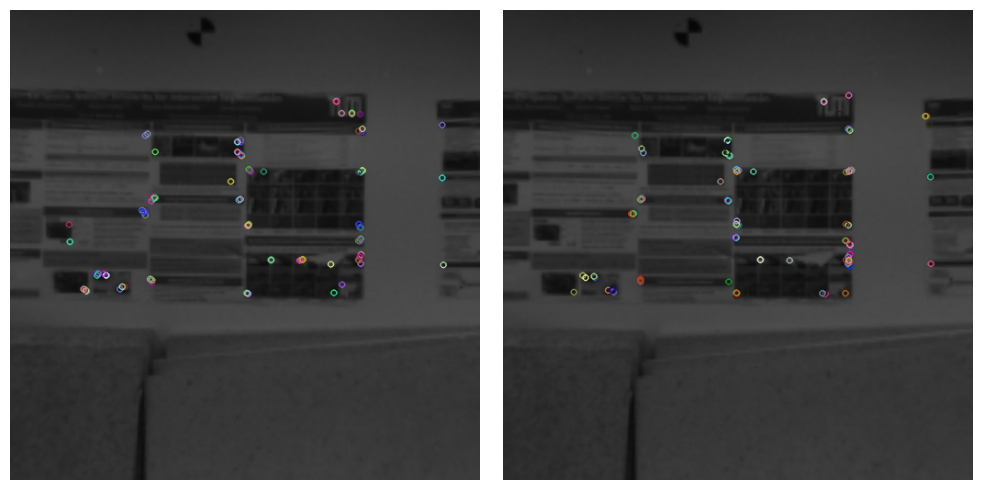

In [6]:
img0_keypoints, img0_descriptors = orb_extrator.extract(images[0])
img1_keypoints, img1_descriptors = orb_extrator.extract(images[1])

image_0_with_keypoints = cv.drawKeypoints(images[0], img0_keypoints, None)
image_1_with_keypoints = cv.drawKeypoints(images[1], img1_keypoints, None)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(image_0_with_keypoints)
ax1.axis('off')

ax2.imshow(image_1_with_keypoints)
ax2.axis('off')


plt.tight_layout()
plt.show()

BruteForce Matcher

In [7]:
bf_config = BFMatcherConfig()
bf_matcher = BFFeatureMatcher(config=bf_config)

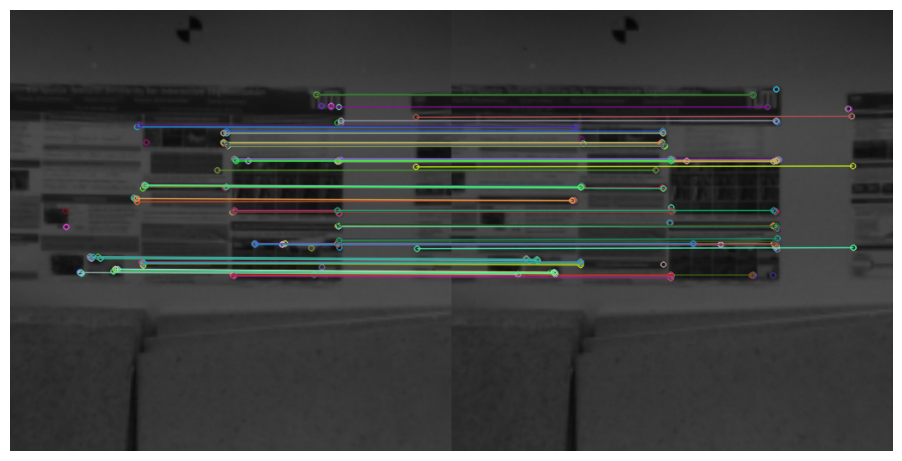

In [8]:
matches = bf_matcher.match(img0_descriptors, img1_descriptors)

images_with_matches = cv.drawMatches(images[0], img0_keypoints, images[1], img1_keypoints, matches, None)

plt.figure(figsize=(10, 5))
plt.imshow(images_with_matches)
plt.tight_layout()
plt.axis('off')
plt.show()

Eightpoint Pose Estimator

In [9]:
eight_point_config = EightPointEstimatorConfig(K=K)
eight_point_pose_estimator = EightPointPoseEstimator(config=eight_point_config)

In [13]:
sorted_kps1 = np.array([img0_keypoints[m.queryIdx].pt for m in matches])
sorted_kps2 = np.array([img1_keypoints[m.trainIdx].pt for m in matches])
eight_point_pose_estimator.estimate(sorted_kps1, sorted_kps2)

{'success': True,
 'R': array([[ 9.99949620e-01,  7.58967468e-03, -6.56915526e-03],
        [-7.58364511e-03,  9.99970800e-01,  9.42283600e-04],
        [ 6.57611507e-03, -8.92417986e-04,  9.99977979e-01]]),
 't': array([[ 0.17260171],
        [-0.05740974],
        [-0.98331723]]),
 'points': 7}